### Lab 05 – Izhikevich Spiking Neuron Model

In this lab, you will implement the Izhikevich neuron model and simulate different biological firing patterns such as regular spiking, fast spiking, and bursting.

You will complete missing code inside `models/izhikevich.py`.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from config import DT, T_TOTAL, I_CONST
from config import REGULAR_SPIKING, FAST_SPIKING, BURSTING
from models.izhikevich import simulate_izhikevich
from utils.plotting import plot_trace, plot_multiple_traces
from utils.metrics import firing_rate, isi, spike_count

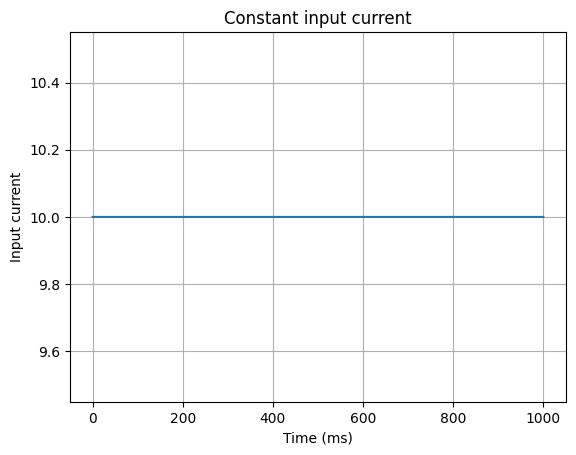

In [10]:
t = np.arange(0, T_TOTAL + DT, DT)
I = np.ones_like(t) * I_CONST

plt.figure()
plt.plot(t, I)
plt.title("Constant input current")
plt.xlabel("Time (ms)")
plt.ylabel("Input current")
plt.grid(True)
plt.show()

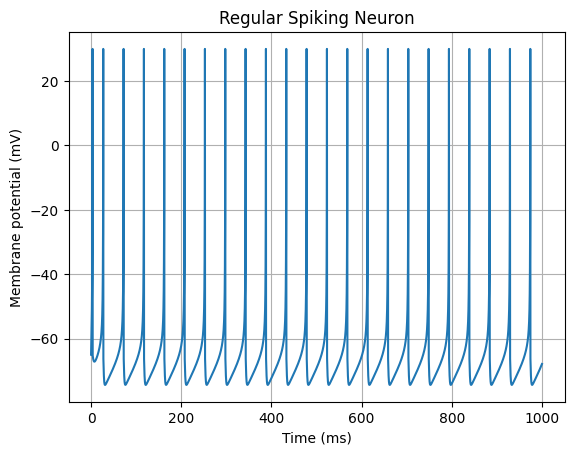

Spike count: 23
Firing rate (Hz): 23.0


In [11]:
# Run regular spiking neuron
params = REGULAR_SPIKING
v_rs, u_rs, sp_rs = simulate_izhikevich(I, t, **params)

plot_trace(t, v_rs, "Regular Spiking Neuron", "Membrane potential (mV)")
print("Spike count:", spike_count(sp_rs))
print("Firing rate (Hz):", firing_rate(sp_rs, 0, T_TOTAL))

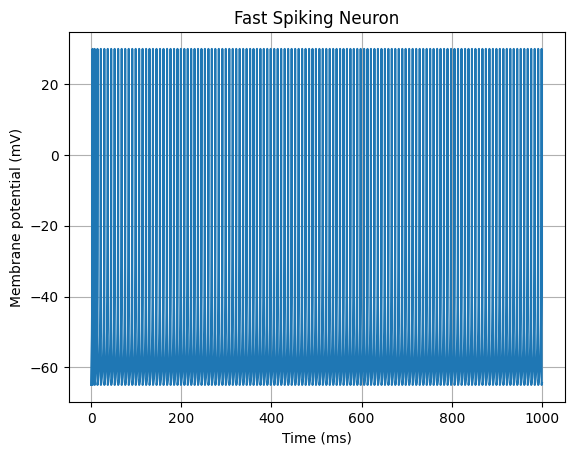

Fast Spiking - Spike count: 131
Fast Spiking - Firing rate (Hz): 131.0


In [12]:
# TODO 3:
# Simulate the fast spiking neuron using FAST_SPIKING parameters
# Plot membrane potential
# Print spike count and firing rate
params_fs = FAST_SPIKING
v_fs, u_fs, sp_fs = simulate_izhikevich(I, t, **params_fs)

plot_trace(t, v_fs, "Fast Spiking Neuron", "Membrane potential (mV)")
print(f"Fast Spiking - Spike count: {spike_count(sp_fs)}")
print(f"Fast Spiking - Firing rate (Hz): {firing_rate(sp_fs, 0, T_TOTAL)}")

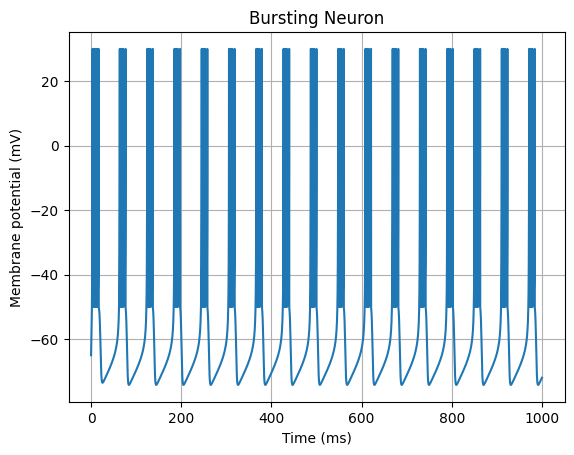

Bursting - Spike count: 87
Bursting - Firing rate (Hz): 87.0


In [13]:
# TODO 4:
# Simulate the bursting neuron using BURSTING parameters
# Plot membrane potential
# Print spike count and firing rate
params_b = BURSTING
v_b, u_b, sp_b = simulate_izhikevich(I, t, **params_b)

plot_trace(t, v_b, "Bursting Neuron", "Membrane potential (mV)")
print(f"Bursting - Spike count: {spike_count(sp_b)}")
print(f"Bursting - Firing rate (Hz): {firing_rate(sp_b, 0, T_TOTAL)}")

In [14]:
# TODO 5:
# Compute and print inter-spike intervals for the regular spiking neuron
regular_isi = isi(sp_rs)
print(f"Regular Spiking ISI: {regular_isi}")

Regular Spiking ISI: [23.7 45.1 45.1 45.1 45.1 45.1 45.1 45.1 45.1 45.1 45.1 45.1 45.1 45.1
 45.1 45.1 45.1 45.1 45.1 45.1 45.1 45.1]


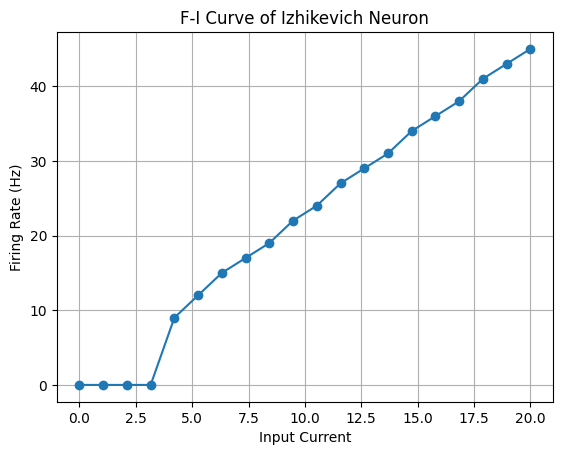

In [15]:
# TODO 6 – F-I Curve Analysis
# Use the Regular Spiking neuron parameters.
# Vary the input current from:

# 0 → 20

# For each current value:
# simulate the neuron
# compute the firing rate
# store the result
# Plot the F–I curve.
currents = np.linspace(0, 20, 20)
rates = []

for I_value in currents:
    
    # Create input current
    I = np.ones_like(t) * I_value
    
    # Run neuron simulation
    v, u, spikes = simulate_izhikevich(I, t, **REGULAR_SPIKING)
    
    # TODO:
    # compute firing rate using spike_times   
    rate = firing_rate(spikes, 0, T_TOTAL)
    
    rates.append(rate)

# Plot F-I curve
plt.figure()
plt.plot(currents, rates, marker='o')
plt.xlabel("Input Current")
plt.ylabel("Firing Rate (Hz)")
plt.title("F-I Curve of Izhikevich Neuron")
plt.grid(True)
plt.show()

In [16]:
## TODO 7 – Short Comparison (3–5 sentences)

# Compare the Izhikevich neuron with the LIF neuron from Lab 4.

# Discuss:
# - biological realism
# - number of firing patterns
# - computational cost
# - when each model is useful

#### The Izhikevich model offers significantly higher biological realism than the Leaky Integrate-and-Fire (LIF) model because it can replicate complex behaviors like bursting and adaptation, which the LIF cannot. While the LIF model is simpler and has a lower computational cost (using only one linear equation), the Izhikevich model remains very efficient by using only two simple differential equations. The LIF model is useful for very large-scale network simulations where individual neuron complexity is less important, whereas the Izhikevich model is ideal when the specific firing pattern of the neuron is critical to the research.